# PyTorch Workflow

Here, we will explore an example of PyTorch ene-to-end workflow

In [8]:
what_will_be_covered = {
    1: "build model",
    2: "fitting the model to data (training)",
    3: "making predictions and evaluating a model (inference)",
    4: "saving and loading a model", 
    5: "putting it all together"
}

what_will_be_covered

{1: 'build model',
 2: 'fitting the model to data (training)',
 3: 'making predictions and evaluating a model (inference)',
 4: 'saving and loading a model',
 5: 'putting it all together'}

In [9]:
import torch
from torch import nn # nn contains all of PyTorch's blocks for neural network
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.12.0+cpu'

## 1. Data (preparing and loading)

Data can be almost anything ... in machine learning
* Excel spreadsheet
* Images of any kind
* Videos (youtube has lots of data)
* Audio like songs or podcasts
* DNA
* Text

Machine learning is a game of two parts:
1. Get data into a numerical representation
2. Build a model/ use a pretrained model to learn patters from that numerical representation

Using a linear regression formular to make a straight line with known **parameters**

In [3]:
# Create known parameters
weight = 0.7
bias = 0.3

# create data
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [4]:
len(X), len(y)

(50, 50)

### Splitting data into training and test sets

One of the most important concepts in machine learning in general

**The Three Datasets**:
1. `Training set`: used in the training process to train model. 
2. `Validation set`: used to tune model patterns. Not seen by model during training. Often but not always needed
3. `Test set`: used to gauge or see if model is ready for deployment.

This is so for the sake of **Generalization**</br>
**Generalization** is the ability for a machine learning to perform well on data it hasn't seen before

Training (60 - 80%), Validation (1 - 20%), Test (10-20)

In [5]:
# Create a train/test split
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [6]:
X_train, y_train

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800],
         [0.2000],
         [0.2200],
         [0.2400],
         [0.2600],
         [0.2800],
         [0.3000],
         [0.3200],
         [0.3400],
         [0.3600],
         [0.3800],
         [0.4000],
         [0.4200],
         [0.4400],
         [0.4600],
         [0.4800],
         [0.5000],
         [0.5200],
         [0.5400],
         [0.5600],
         [0.5800],
         [0.6000],
         [0.6200],
         [0.6400],
         [0.6600],
         [0.6800],
         [0.7000],
         [0.7200],
         [0.7400],
         [0.7600],
         [0.7800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260],
         [0.4400],
         [0.4540],
         [

How to better visualize the data.-- Visualization

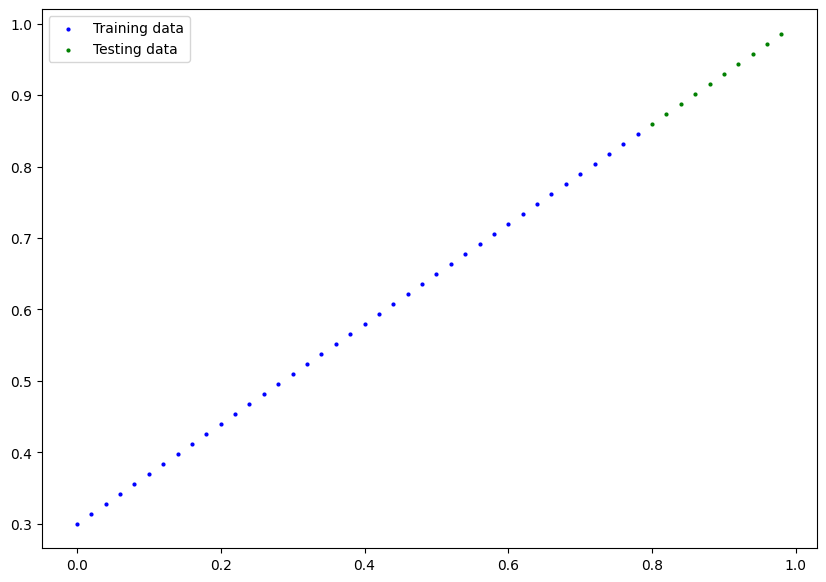

In [7]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
    """
    plots training data, test data and compares predictions
    """
    plt.figure(figsize=(10, 7))

    # plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

    # plot test data in green 
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

    # Are there predictions?
    if predictions is not None:
        # plot predictions if there is any
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    # show the legend
    plt.legend(prop={"size": 10});

plot_predictions();

We are going to build a model to try and learn the patterns in the blue dot so that if we fed the x-values of the green dot, it could correctly predict the y values 

## 2. Building our First PyTorch model

Linear regression model: `y = mx + c`, y is the dependent variable, x is the independent variable, m is the gradient and c is the intercept

In [16]:
# create a linear regression model class
class LinearRegressionModel(nn.Module):       # our class inherits from nn.Module (everything in PyTorch inherits from nn.Module). Base class for all neural network modules
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,
                                               requires_grad=True,
                                               dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1,
                                            requires_grad=True,
                                            dtype=torch.float))

        # Forward method to define the computation in model
        def forward(self, x: torch.Tensor) -> torch.Tensor:
            return self.weights * x + self.bias
    
    

- Models the relationship between a set of **predictors** (independent variables) and a **dependent variable**
- This relationship is **defined** by two learnable parameters: **weights** and **bias**
- The goal of training is to find the optimal weights and bias such that the model can predict the dependent variable as accurately as possible

### Training Process
- Weights and biases are **initialized** (often randomly or as zeros)
- The model learns patterns in the predictor data and iteratively **updates** the weights and bias to minimize prediction error
- Updates continue until the parameters **converge** — i.e., their values stabilize as close to optimal as possible
- The final settled values are then used for **inference** (making predictions on new data)

> Linear regression learns the weights and bias that **minimize the difference between predicted and true outputs**, not because it knows the true parameters, but because minimizing loss is how it approximates them.


**What our model up does**: 
* Start with random values (weights and bias)
* Look at training data and adjust the random values to better represent (or get closer to) the ideal values (the known or true weight and bias of the data).

**How does it do so**

Through two main algorithms:
1. Gradient descent (`requires_grad=True`) - [gradient descent](https://youtu.be/IHZwWFHWa-w?si=E0Gk3YNByib_fubq)
2. Backpropagation - [backpropagation](https://youtu.be/Ilg3gGewQ5U?si=-AkJlZyG3B5QFXEk)